C:\Users\qingy\AppData\Local\Temp\ipykernel_16308\1463003004.py:134: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\qingy\AppData\Local\Temp\ipykernel_16308\1463003004.py:134: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
D:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


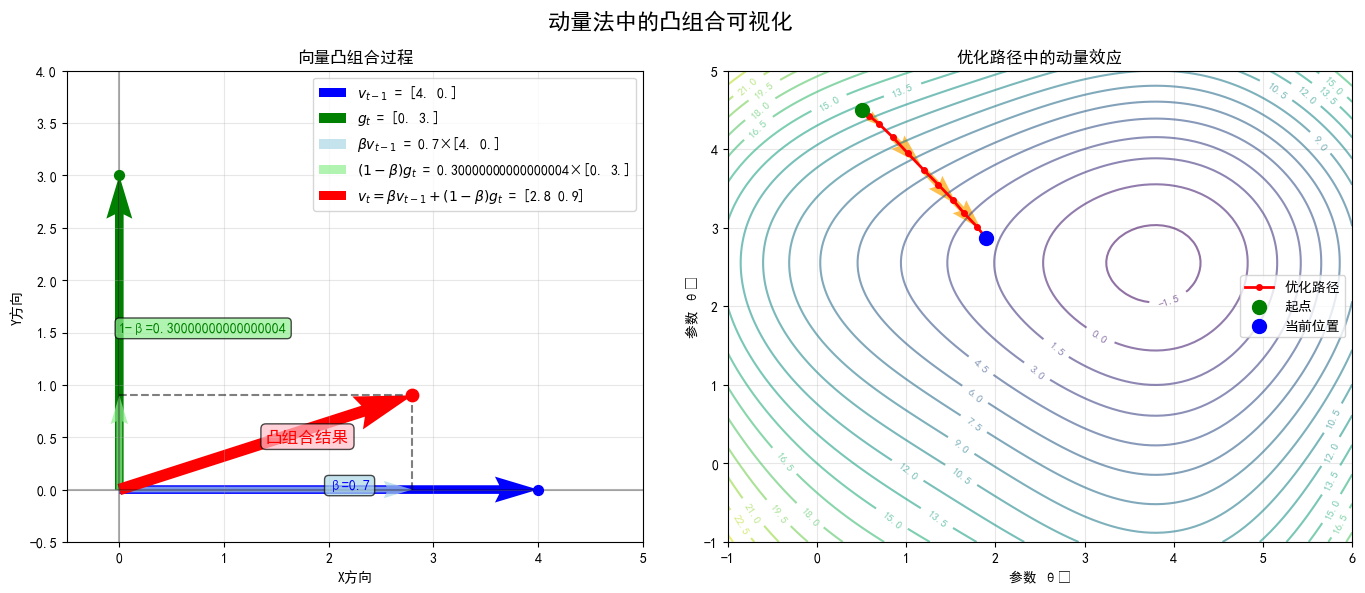

计算详情:
历史速度向量 v_{t-1} = [4. 0.]
当前梯度向量 g_t = [0. 3.]
缩放后的历史向量 β·v_{t-1} = 0.7 × [4. 0.] = [2.8 0. ]
缩放后的当前向量 (1-β)·g_t = 0.30000000000000004 × [0. 3.] = [0.  0.9]
凸组合结果 v_t = [2.8 0. ] + [0.  0.9] = [2.8 0.9]
权重验证: β + (1-β) = 0.7 + 0.30000000000000004 = 1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 定义参数
beta = 0.7  # 动量参数
eta = 0.1   # 学习率

# 初始化向量
v_prev = np.array([4.0, 0.0])  # 历史速度向量 v_{t-1}
g_t = np.array([0.0, 3.0])     # 当前梯度向量 g_t

# 计算凸组合
v_t = beta * v_prev + (1 - beta) * g_t

# 创建图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('动量法中的凸组合可视化', fontsize=16, fontweight='bold')

# 第一个子图：向量分解和凸组合过程
ax1.set_title('向量凸组合过程')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 5)
ax1.set_ylim(-0.5, 4)
ax1.set_aspect('equal')

# 绘制坐标轴
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# 绘制向量
origin = np.array([0, 0])

# 绘制历史速度向量
ax1.quiver(*origin, *v_prev, color='blue', scale=1, scale_units='xy', angles='xy', 
          label=f'$v_{{t-1}}$ = {v_prev}', width=0.015)

# 绘制当前梯度向量
ax1.quiver(*origin, *g_t, color='green', scale=1, scale_units='xy', angles='xy',
          label=f'$g_t$ = {g_t}', width=0.015)

# 绘制缩放后的向量
scaled_v_prev = beta * v_prev
scaled_g_t = (1 - beta) * g_t

ax1.quiver(*origin, *scaled_v_prev, color='lightblue', scale=1, scale_units='xy', 
          angles='xy', alpha=0.7, width=0.01, label=f'$\\beta v_{{t-1}}$ = {beta}×{v_prev}')

ax1.quiver(*origin, *scaled_g_t, color='lightgreen', scale=1, scale_units='xy', 
          angles='xy', alpha=0.7, width=0.01, label=f'$(1-\\beta)g_t$ = {1-beta}×{g_t}')

# 绘制凸组合结果向量
ax1.quiver(*origin, *v_t, color='red', scale=1, scale_units='xy', angles='xy',
          label=f'$v_t = \\beta v_{{t-1}} + (1-\\beta)g_t$ = {v_t}', width=0.02)

# 绘制连接线（显示凸组合的几何意义）
ax1.plot([scaled_v_prev[0], v_t[0]], [scaled_v_prev[1], v_t[1]], 'k--', alpha=0.5)
ax1.plot([scaled_g_t[0], v_t[0]], [scaled_g_t[1], v_t[1]], 'k--', alpha=0.5)

# 标记点
ax1.scatter(*v_prev, color='blue', s=50, zorder=5)
ax1.scatter(*g_t, color='green', s=50, zorder=5)
ax1.scatter(*v_t, color='red', s=80, zorder=5)

# 添加文本标注
ax1.text(v_prev[0]/2, v_prev[1]/2, f'β={beta}', color='blue', fontsize=10, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
ax1.text(g_t[0]/2, g_t[1]/2, f'1-β={1-beta}', color='green', fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
ax1.text(v_t[0]/2, v_t[1]/2, '凸组合结果', color='red', fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="pink", alpha=0.7))

ax1.legend(loc='upper right')
ax1.set_xlabel('X方向')
ax1.set_ylabel('Y方向')

# 第二个子图：优化路径示意图
ax2.set_title('优化路径中的动量效应')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-1, 6)
ax2.set_ylim(-1, 5)

# 创建一个简单的损失曲面示意
x = np.linspace(-1, 6, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
Z = (X-3)**2 + (Y-2)**2 + 2*np.sin(X) + 2*np.cos(Y)

# 绘制等高线
contour = ax2.contour(X, Y, Z, levels=20, alpha=0.6, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)

# 模拟优化路径
theta_path = [np.array([0.5, 4.5])]  # 初始参数
v_path = [np.array([0.0, 0.0])]     # 初始速度

for i in range(10):
    # 模拟梯度（这里用负梯度方向指向最小值）
    grad = -(theta_path[-1] - np.array([3.0, 2.0])) + 0.5 * np.random.randn(2)
    
    # 动量更新
    v_new = beta * v_path[-1] + (1 - beta) * grad
    theta_new = theta_path[-1] + eta * v_new  # 注意这里是+号，因为grad已经是负梯度方向
    
    v_path.append(v_new)
    theta_path.append(theta_new)

# 绘制优化路径
theta_path = np.array(theta_path)
ax2.plot(theta_path[:, 0], theta_path[:, 1], 'ro-', linewidth=2, markersize=4, 
        label='优化路径')
ax2.scatter(theta_path[0, 0], theta_path[0, 1], color='green', s=100, 
           label='起点', zorder=5)
ax2.scatter(theta_path[-1, 0], theta_path[-1, 1], color='blue', s=100, 
           label='当前位置', zorder=5)

# 在几个点绘制速度向量
for i in [1, 3, 5, 7]:
    if i < len(theta_path):
        ax2.quiver(theta_path[i, 0], theta_path[i, 1], 
                  v_path[i][0], v_path[i][1], 
                  color='orange', scale=5, scale_units='xy', 
                  angles='xy', width=0.01, alpha=0.7)

ax2.legend()
ax2.set_xlabel('参数 θ₁')
ax2.set_ylabel('参数 θ₂')

plt.tight_layout()
plt.show()

# 打印计算详情
print("计算详情:")
print(f"历史速度向量 v_{{t-1}} = {v_prev}")
print(f"当前梯度向量 g_t = {g_t}")
print(f"缩放后的历史向量 β·v_{{t-1}} = {beta} × {v_prev} = {scaled_v_prev}")
print(f"缩放后的当前向量 (1-β)·g_t = {1-beta} × {g_t} = {scaled_g_t}")
print(f"凸组合结果 v_t = {scaled_v_prev} + {scaled_g_t} = {v_t}")
print(f"权重验证: β + (1-β) = {beta} + {1-beta} = 1.0")